# CarDD — test du biais de source (généralise-t-il aux vraies photos ?)

Le modèle est entraîné sur des photos **stock "propres"** (Flickr/Shutterstock). Question BC04 :
tient-il sur de **vraies photos d'annonce** (leboncoin / paruvendu) ?

Test **qualitatif** sur 3 photos réelles à vérité terrain connue (1 intacte, 1 avec dent, 1 avec
rayures). On regarde si les prédictions sont plausibles. Photos non versionnées (`dl/data/**`).

In [1]:
import sys; sys.path.insert(0, '../../src')
import importlib, infer, device as devmod
importlib.reload(devmod); importlib.reload(infer)
from infer import load_model, predict
from pathlib import Path
from PIL import Image
import urllib.request
import matplotlib.pyplot as plt

model, classes, device = load_model('../../models/cardd_multilabel_resnet18.pt')
print('modèle chargé sur', device)
RAW = Path('../../data/real_test/raw'); RAW.mkdir(parents=True, exist_ok=True)

modèle chargé sur mps


In [2]:
# --- Cas réels (fichier, vérité terrain, URL). CDN hors DataDome, fetch direct. ---
EXAMPLES = [
    ('01_intact.jpg', 'intact (aucun dégât)',
     'https://img.leboncoin.fr/api/v1/lbcpb1/images/a4/51/3a/a4513a41fe8a5e78c60e8026d6bbeb5b5c371bea.jpg?rule=ad-large'),
    ('02_dent.jpg', 'dent (enfoncement aile av. droite)',
     'https://img.paruvendu.fr/media_ext/_https_/media.paruvendu.fr/99/71/L21lZGlhLXBhL1dWMTcvNy8yL1dWMTc3MjE1NDEwXzEuanBlZz8yMDI2MDUwNDE1MjUwOQ_rct?func=crop&w=1000&gravity=auto'),
    ('03_scratch.jpg', 'scratch (rayures)',
     'https://img.paruvendu.fr/media_ext/_https_/media.paruvendu.fr/7b/ab/L21lZGlhLXBhL1dWMTcvNy8zL1dWMTc3MzU1MDczXzMuanBlZz8yMDI2MDYwNTExNTIxMA_rct?func=crop&w=1000&gravity=auto'),
]
HEADERS = {'User-Agent': 'Mozilla/5.0', 'Referer': 'https://www.google.com/'}
for fn, _, url in EXAMPLES:
    if (RAW / fn).exists():
        continue
    req = urllib.request.Request(url, headers=HEADERS)
    (RAW / fn).write_bytes(urllib.request.urlopen(req, timeout=25).read())
    print('téléchargé', fn)
print('images prêtes :', [fn for fn, _, _ in EXAMPLES])

images prêtes : ['01_intact.jpg', '02_dent.jpg', '03_scratch.jpg']


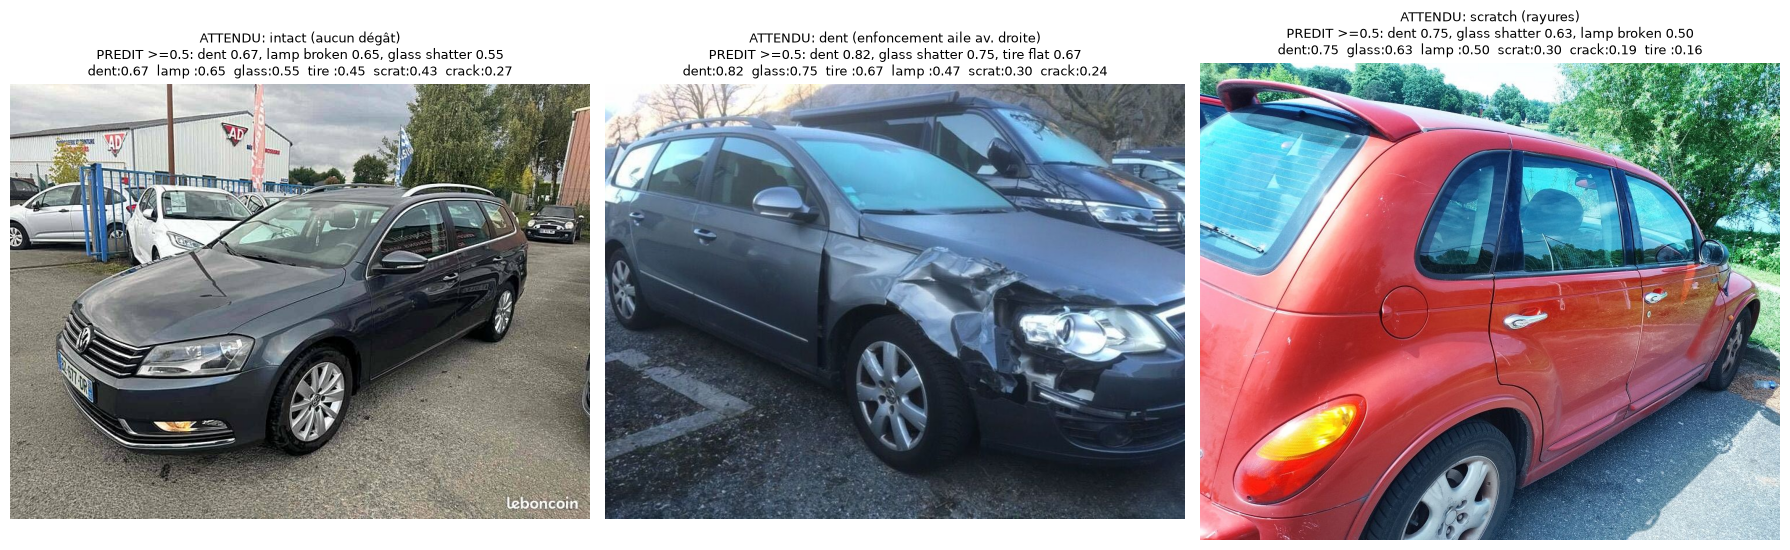

In [3]:
# --- Prédiction : attendu vs prédit ---
fig, axes = plt.subplots(1, len(EXAMPLES), figsize=(6 * len(EXAMPLES), 6))
for ax, (fn, expected, _) in zip(axes, EXAMPLES):
    img = Image.open(RAW / fn)
    probs = predict(model, classes, device, img)
    top = sorted(probs.items(), key=lambda kv: -kv[1])
    present = [f'{c} {v:.2f}' for c, v in top if v >= 0.5] or ['(aucun >= 0.5)']
    ax.imshow(img); ax.axis('off')
    ax.set_title(f'ATTENDU: {expected}\nPREDIT >=0.5: ' + ', '.join(present)
                 + '\n' + '  '.join(f'{c[:5]}:{v:.2f}' for c, v in top), fontsize=9)
plt.tight_layout(); plt.show()

## Lecture — biais de source confirmé (résultat BC04)

Sur les 3 vraies photos, le modèle **ne généralise pas** :

- **Intacte** → prédit plusieurs dégâts (dent, lamp broken, glass shatter > 0.5) : **invente des
  dégâts sur une voiture propre**.
- **Dent réelle** → trouve bien `dent`, mais ajoute `glass shatter` / `tire flat` (faux positifs).
- **Rayures** → **rate le scratch** (~0.30) et prédit `dent` à la place.

Les probabilités deviennent **molles** (toutes vers 0.4–0.8) alors qu'elles étaient nettes sur le
test CarDD : classique **décalage de distribution** (domain shift). Le modèle a appris le *style*
CarDD (photos stock cadrées), pas le dégât en soi. `glass shatter` — la meilleure classe sur CarDD —
se sur-déclenche systématiquement sur le réel.

**Conséquence** : le macro-F1 0.69 mesuré sur CarDD **n'est pas transférable** aux photos d'annonce
réelles. À dire explicitement dans toute restitution produit (transparence + gestion du biais, cœur
BC04). Pistes : fine-tuning sur photos réelles annotées, augmentation plus agressive, ou collecte
d'un jeu réel — à arbitrer plus tard.